# 03 — Demand Validation
**Phase 3: Validate the demand distribution**

**Part A:** Weekday vs pooled comparison (log-likelihood test)
**Part B:** Monte Carlo simulation validation (histogram comparison)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data/processed"
FIG_DIR  = "../outputs/figures"
TBL_DIR  = "../outputs/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

ALPHA = 1.0
SEED = 42
SIM_N = 500
SIM_T = 30
WEEKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

## Part A: Weekday vs pooled — is a single P(D) justified?

In [2]:
df_wd = pd.read_csv(os.path.join(DATA_DIR, "sandwich_daily_by_weekday.csv"), parse_dates=["Date"])
df_wd["D"] = df_wd[WEEKDAY_ORDER].sum(axis=1).astype(int)
df_wd["dow"] = df_wd["Date"].dt.day_name()
df_wd = df_wd.sort_values("Date").reset_index(drop=True)

Dmax = int(df_wd["D"].max())
support = np.arange(Dmax + 1)

# Weekday summary
summary = []
for w in WEEKDAY_ORDER:
    mask = df_wd["Date"].dt.day_name() == w
    D = df_wd.loc[mask, w].astype(int)
    summary.append({"Day": w, "n_days": len(D), "mean": round(D.mean(),2),
                    "median": D.median(), "std": round(D.std(),2),
                    "p95": D.quantile(0.95), "P(D=0)": round((D==0).mean(),4)})

summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(TBL_DIR, "weekday_summary.csv"), index=False)
print(summary_df.to_string(index=False))

      Day  n_days  mean  median  std   p95  P(D=0)
   Monday      51  9.22     9.0 5.73 19.00  0.0588
  Tuesday      52  9.73     8.0 6.31 21.45  0.0192
Wednesday      52  7.77     8.0 4.50 16.00  0.0577
 Thursday      52  8.92     8.0 5.71 18.45  0.0769
   Friday      52  7.94     7.5 5.57 18.45  0.0577
 Saturday      52  9.60     9.0 5.06 18.35  0.0192
   Sunday      53  9.57     8.0 5.93 19.40  0.0189


### Weekday PMF panels

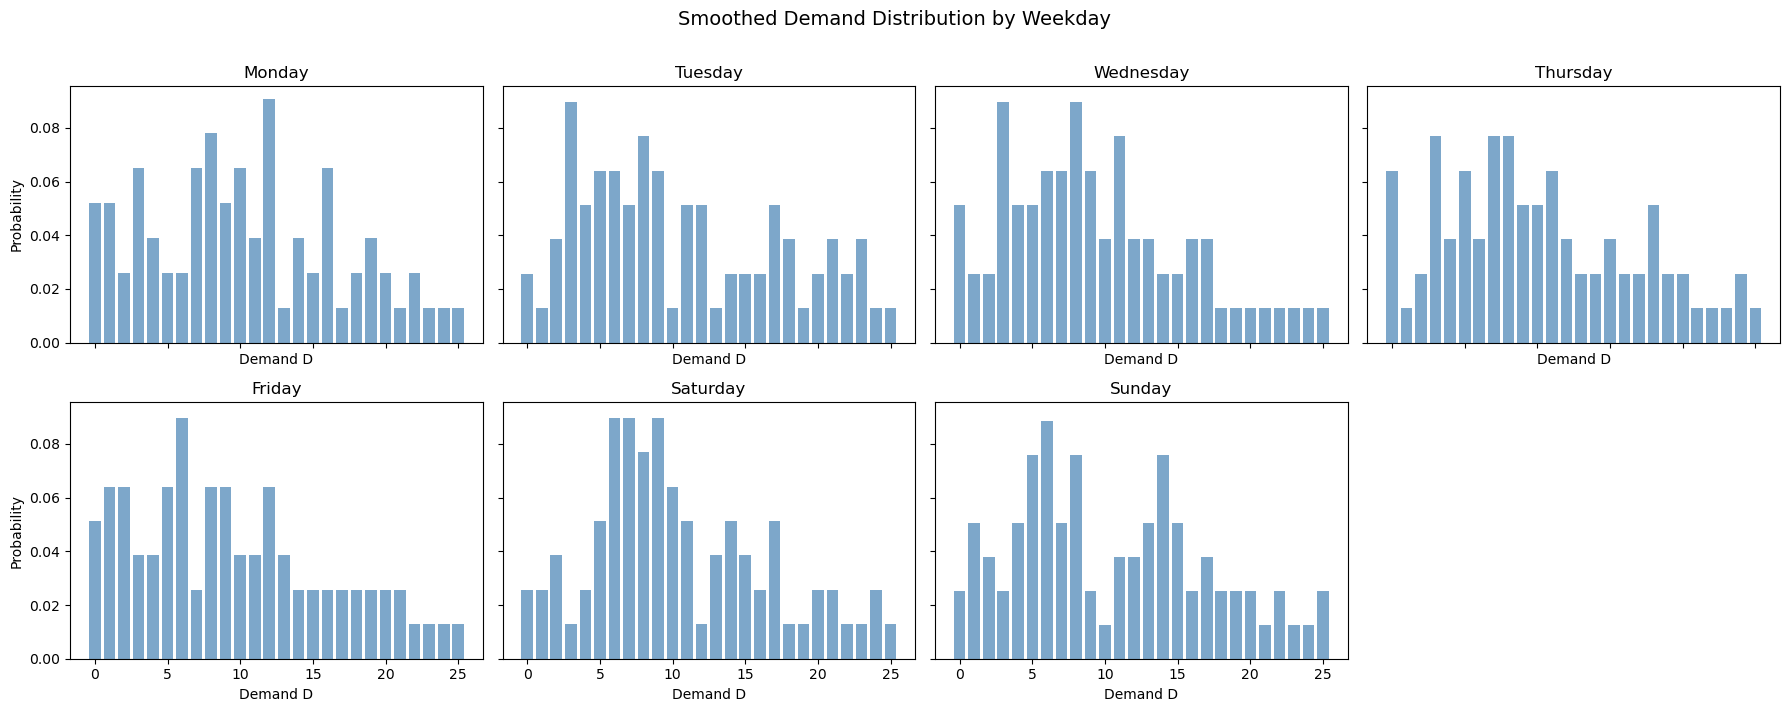

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.flatten()
for i, w in enumerate(WEEKDAY_ORDER):
    mask = df_wd["Date"].dt.day_name() == w
    D = df_wd.loc[mask, w].astype(int)
    counts = D.value_counts().reindex(range(Dmax+1), fill_value=0).sort_index()
    P_smo = (counts + ALPHA) / (counts.sum() + ALPHA * (Dmax+1))
    axes[i].bar(range(Dmax+1), P_smo.values, color="steelblue", alpha=0.7)
    axes[i].set_title(w)
    axes[i].set_xlabel("Demand D")
    if i % 4 == 0: axes[i].set_ylabel("Probability")
axes[-1].axis("off")
fig.suptitle("Smoothed Demand Distribution by Weekday", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "weekday_pmf_panels.png"), dpi=150, bbox_inches="tight")
plt.show()

### Log-likelihood comparison (80/20 train/test)

In [4]:
cut = int(len(df_wd) * 0.8)
train, test = df_wd.iloc[:cut].copy(), df_wd.iloc[cut:].copy()
Dmax_t = int(train["D"].max())
sup = np.arange(Dmax_t + 1)

counts_pool = train["D"].value_counts().reindex(sup, fill_value=0).sort_index()
P_pool = (counts_pool + ALPHA) / (counts_pool.sum() + ALPHA * len(sup))

P_dow = {}
for w in WEEKDAY_ORDER:
    g = train[train["dow"]==w]["D"].astype(int)
    c = g.value_counts().reindex(sup, fill_value=0).sort_index()
    P_dow[w] = (c + ALPHA) / (c.sum() + ALPHA * len(sup))

def prob_from(pmf, d):
    d = int(min(max(d, 0), Dmax_t))
    return float(pmf.iloc[d])

ll_pool = sum(np.log(prob_from(P_pool, int(r["D"]))) for _, r in test.iterrows())
ll_dow  = sum(np.log(prob_from(P_dow[r["dow"]], int(r["D"]))) for _, r in test.iterrows())

print(f"Avg test log-likelihood (pooled):  {ll_pool/len(test):.4f}")
print(f"Avg test log-likelihood (weekday): {ll_dow/len(test):.4f}")
print(f"Difference (weekday - pooled):     {(ll_dow-ll_pool)/len(test):.4f}")
winner = "POOLED" if ll_pool >= ll_dow else "WEEKDAY"
print(f"→ {winner} model wins on held-out data")

loglik_df = pd.DataFrame({"Model": ["Pooled","Weekday"], "Avg_Test_LogLik": [ll_pool/len(test), ll_dow/len(test)]})
loglik_df.to_csv(os.path.join(TBL_DIR, "weekday_loglik_comparison.csv"), index=False)

Avg test log-likelihood (pooled):  -3.0436
Avg test log-likelihood (weekday): -3.1532
Difference (weekday - pooled):     -0.1096
→ POOLED model wins on held-out data


## Part B: Monte Carlo simulation validation

In [5]:
P_df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_P_of_D.csv"))
values = P_df["Demand_D"].to_numpy()
probs = P_df["P_smoothed"].to_numpy()

df_clean = pd.read_csv(os.path.join(DATA_DIR, "sandwich_daily_demand_cleaned.csv"), parse_dates=["Date"])
hist_demand = df_clean["Daily_Demand"].to_numpy()

rng = np.random.default_rng(SEED)
paths = rng.choice(values, size=(SIM_N, SIM_T), p=probs)

### Simulated demand paths

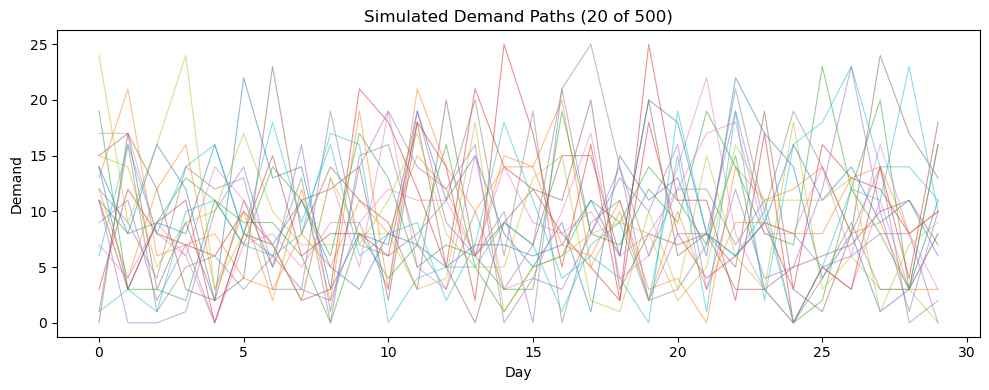

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(20): ax.plot(paths[i], alpha=0.5, linewidth=0.8)
ax.set_xlabel("Day"); ax.set_ylabel("Demand")
ax.set_title(f"Simulated Demand Paths (20 of {SIM_N})")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "simulated_demand_paths.png"), dpi=150)
plt.show()

### Historical vs simulated histogram

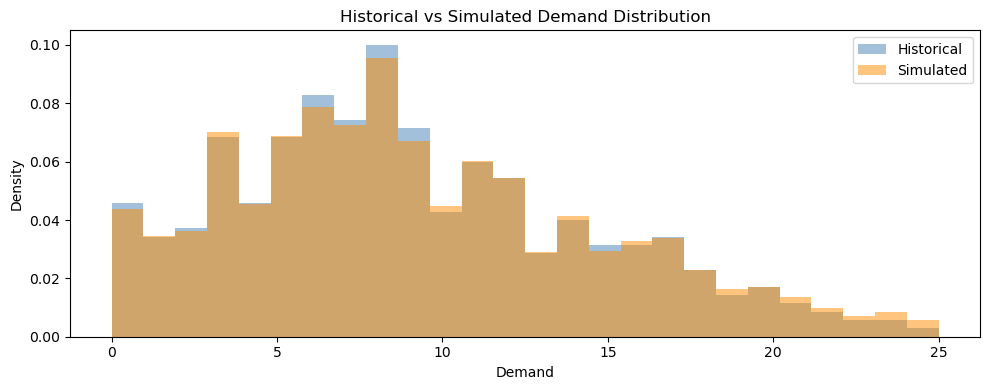

                       Historical    Simulated
                Mean         8.96         9.17
             Std Dev         5.57         5.76
              Median          8.0          8.0


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hist_demand, bins=26, alpha=0.5, density=True, label="Historical", color="steelblue")
ax.hist(paths.flatten(), bins=26, alpha=0.5, density=True, label="Simulated", color="darkorange")
ax.set_xlabel("Demand"); ax.set_ylabel("Density")
ax.set_title("Historical vs Simulated Demand Distribution")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "simulated_vs_historical.png"), dpi=150)
plt.show()

sim_flat = paths.flatten()
print(f"{'':>20s} {'Historical':>12s} {'Simulated':>12s}")
print(f"{'Mean':>20s} {hist_demand.mean():>12.2f} {sim_flat.mean():>12.2f}")
print(f"{'Std Dev':>20s} {hist_demand.std():>12.2f} {sim_flat.std():>12.2f}")
print(f"{'Median':>20s} {np.median(hist_demand):>12.1f} {np.median(sim_flat):>12.1f}")